In [ ]:
from google import 
import pandas as pd

conn=duckdb.connect('/mnt/c/Users/yasab/OneDrive/Desktop/Lean Data pipleine/ingestion/crypto_data.db')

print(conn.execute("SHOW TABLES").fetchall())

[('crypto_data',), ('crypto_data_table',), ('marts_coin',), ('stg_coins',)]


In [ ]:
df=conn.execute("""
    SELECT name, COUNT(*) AS snapshots,
        MIN(ingested_at) as first_fetch,
        MAX(ingested_at) AS last_fetch
     FROM crypto_data
     GROUP BY name
     ORDER BY snapshots DESC
     """).df()
df

,name,snapshots,first_fetch,last_fetch
0,Tether,217,1779034944420,2026-05-08T14:20:56.853600
1,XRP,217,1779034944420,2026-05-08T14:20:56.853600
2,Avalanche,217,1779034944420,2026-05-08T14:20:56.853600
3,Sui,217,1779034944420,2026-05-08T14:20:56.853600
4,Shiba Inu,217,1779034944420,2026-05-08T14:20:56.853600
5,Ethereum,217,1779034944420,2026-05-08T14:20:56.853600
6,BlackRock USD Institutional Digital Liquidity ...,217,1779034944420,2026-05-08T14:20:56.853600
7,Bitcoin Cash,217,1779034944420,2026-05-08T14:20:56.853600
8,Canton,217,1779034944420,2026-05-08T14:20:56.853600
9,Circle USYC,217,1779034944420,2026-05-08T14:20:56.853600


In [ ]:
df2 = conn.execute("""
    SELECT 
        name,
        current_price,
        market_cap,
        total_volume,
        CASE 
            WHEN ingested_at LIKE '2026%' OR ingested_at LIKE '2025%'
            THEN ingested_at::timestamp
            ELSE to_timestamp(CAST(ingested_at AS BIGINT) / 1000)
        END as ingested_at
    FROM crypto_data
    ORDER BY ingested_at ASC
""").df()

df2.head(10)

,name,current_price,market_cap,total_volume,ingested_at
0,Bitcoin,80210.000000,1606071624546,3.850698e+10,2026-05-08 14:20:56.853600+03:00
1,Ethereum,2290.890000,276416249441,2.199396e+10,2026-05-08 14:20:56.853600+03:00
2,Tether,0.999833,189683200164,6.932968e+10,2026-05-08 14:20:56.853600+03:00
3,BNB,640.240000,86283557500,1.018982e+09,2026-05-08 14:20:56.853600+03:00
4,XRP,1.390000,85877816008,1.616158e+09,2026-05-08 14:20:56.853600+03:00
5,USDC,0.999881,78368037174,1.430390e+10,2026-05-08 14:20:56.853600+03:00
6,Solana,88.560000,51140023006,3.377094e+09,2026-05-08 14:20:56.853600+03:00
7,TRON,0.347883,32981086804,5.156663e+08,2026-05-08 14:20:56.853600+03:00
8,Figure Heloc,1.003000,17540293663,8.252434e+08,2026-05-08 14:20:56.853600+03:00
9,Dogecoin,0.107413,16556321789,1.336362e+09,2026-05-08 14:20:56.853600+03:00


In [ ]:
# Check data
print(f"Total Rows: {df2.shape[0]}")
print(f"Total columns: {df2.columns}")
print(f"\nDate range: {df2['ingested_at'].min()} → {df2['ingested_at'].max()}")
print(f"\nUnique coins: {df2['name'].nunique()}")
print(f"\nData types:\n{df2.dtypes}")


Total Rows: 10850
Total columns: Index(['name', 'current_price', 'market_cap', 'total_volume', 'ingested_at'], dtype='str')

Date range: 2026-05-08 14:20:56.853600+03:00 → 2026-06-09 20:30:09.395000+03:00

Unique coins: 55

Data types:
name                                        str
current_price                           float64
market_cap                                int64
total_volume                            float64
ingested_at      datetime64[us, Africa/Nairobi]
dtype: object


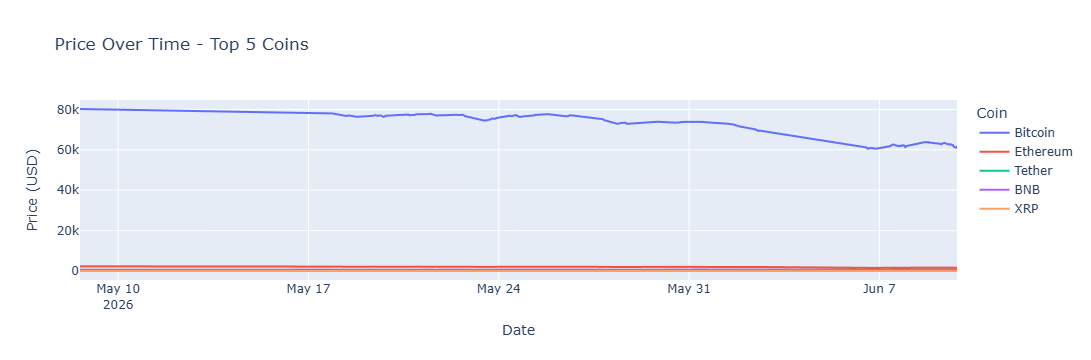

In [ ]:
import plotly.express as px

# Filter top 5 coins by market cap
top5 = ['Bitcoin', 'Ethereum', 'Tether', 'BNB', 'XRP']

df_top5 = df2[df2['name'].isin(top5)].copy()

fig = px.line(
    df_top5, 
    x='ingested_at', 
    y='current_price', 
    color='name',
    title='Price Over Time - Top 5 Coins',
    labels={'current_price': 'Price (USD)', 'ingested_at': 'Date', 'name': 'Coin'}
)

fig.show()

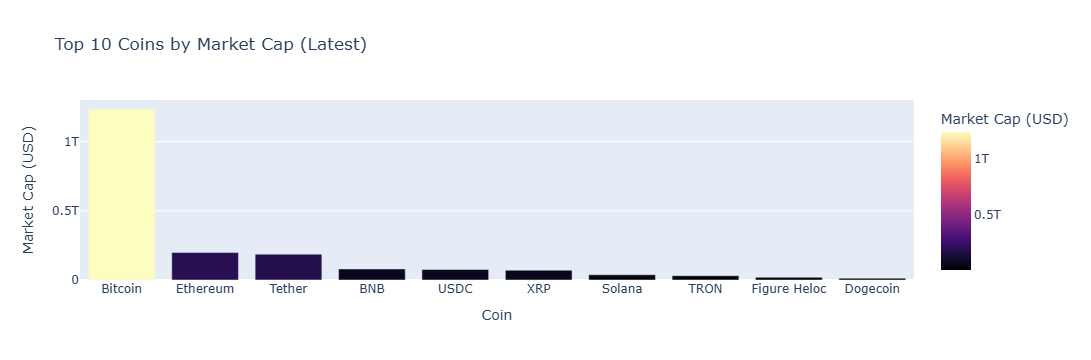

In [ ]:
# Latest snapshot only - top coins by market cap
df_latest = df2.sort_values('ingested_at').groupby('name').last().reset_index()

df_top = df_latest.sort_values('market_cap', ascending=False).head(10)

fig = px.bar(
    df_top,
    x='name',
    y='market_cap',
    title='Top 10 Coins by Market Cap (Latest)',
    labels={'market_cap': 'Market Cap (USD)', 'name': 'Coin'},
    color='market_cap',
    color_continuous_scale='Magma'
)

fig.show()

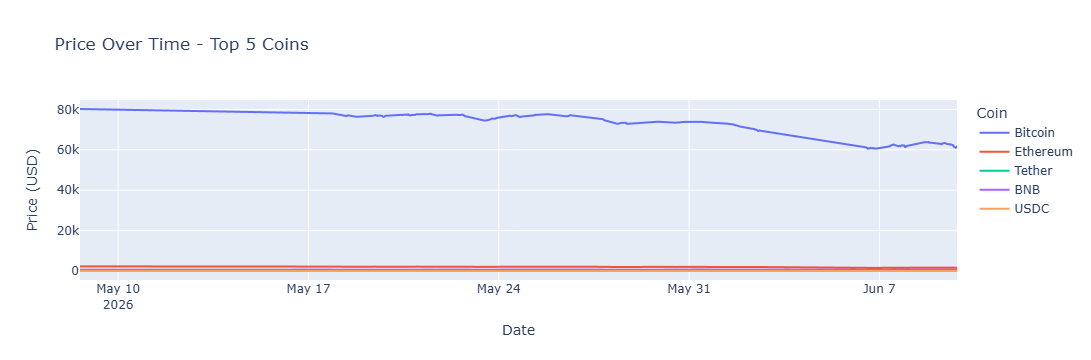

In [ ]:
import plotly.express as px

top_5=['Bitcoin','Ethereum','Tether','BNB','USDC']

df_top_5=df2[df2['name'].isin(top_5)].copy()

fig=px.line(
    df_top_5,
    x='ingested_at', 
    y='current_price', 
    color='name',
    title='Price Over Time - Top 5 Coins',
    labels={'current_price': 'Price (USD)', 'ingested_at': 'Date', 'name': 'Coin'}
)

fig.show()
    

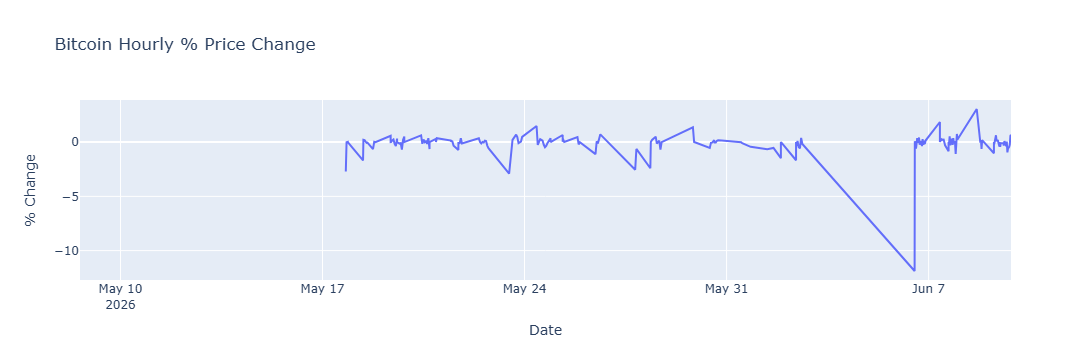

In [ ]:
# Calculate hourly % price change per coin
df2 = df2.sort_values(['name', 'ingested_at'])

df2['pct_change'] = df2.groupby('name')['current_price'].pct_change() * 100

# Show Bitcoin specifically
btc = df2[df2['name'] == 'Bitcoin'].copy()

fig = px.line(
    btc,
    x='ingested_at',
    y='pct_change',
    title='Bitcoin Hourly % Price Change',
    labels={'pct_change': '% Change', 'ingested_at': 'Date'}
)

fig.show()

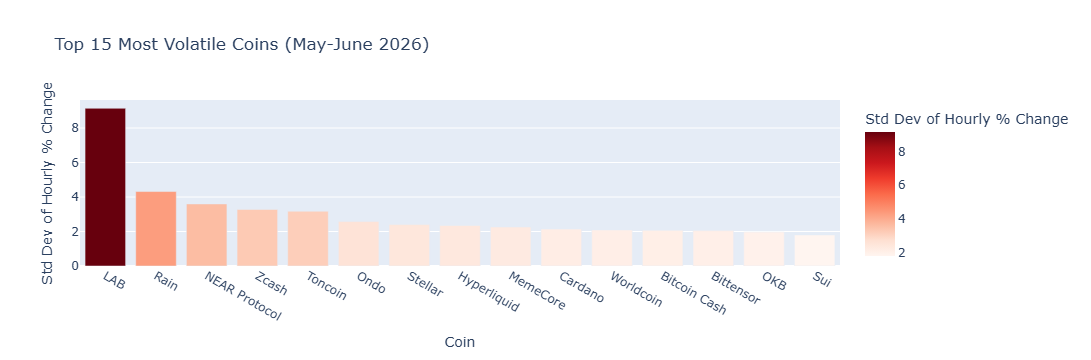

In [ ]:
volatility = df2.groupby('name')['pct_change'].std().reset_index()
volatility.columns = ['name', 'volatility']
volatility = volatility.sort_values('volatility', ascending=False).head(15)

fig = px.bar(
    volatility,
    x='name',
    y='volatility',
    title='Top 15 Most Volatile Coins (May-June 2026)',
    labels={'volatility': 'Std Dev of Hourly % Change', 'name': 'Coin'},
    color='volatility',
    color_continuous_scale='Reds'
)
fig.show()

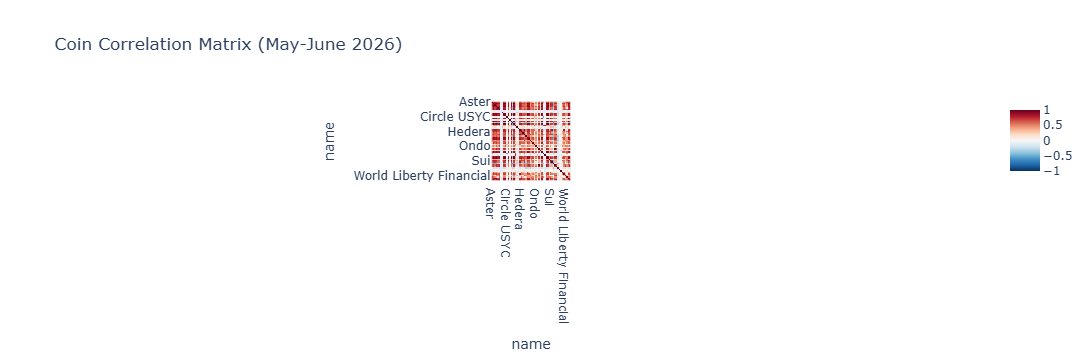

In [ ]:
# Pivot table - each coin becomes a column, rows are timestamps
df_pivot = df2.pivot_table(
    index='ingested_at', 
    columns='name', 
    values='pct_change'
)

# Correlation matrix
corr = df_pivot.corr()

import plotly.figure_factory as ff
import numpy as np

fig = px.imshow(
    corr,
    title='Coin Correlation Matrix (May-June 2026)',
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1
)
fig.show()

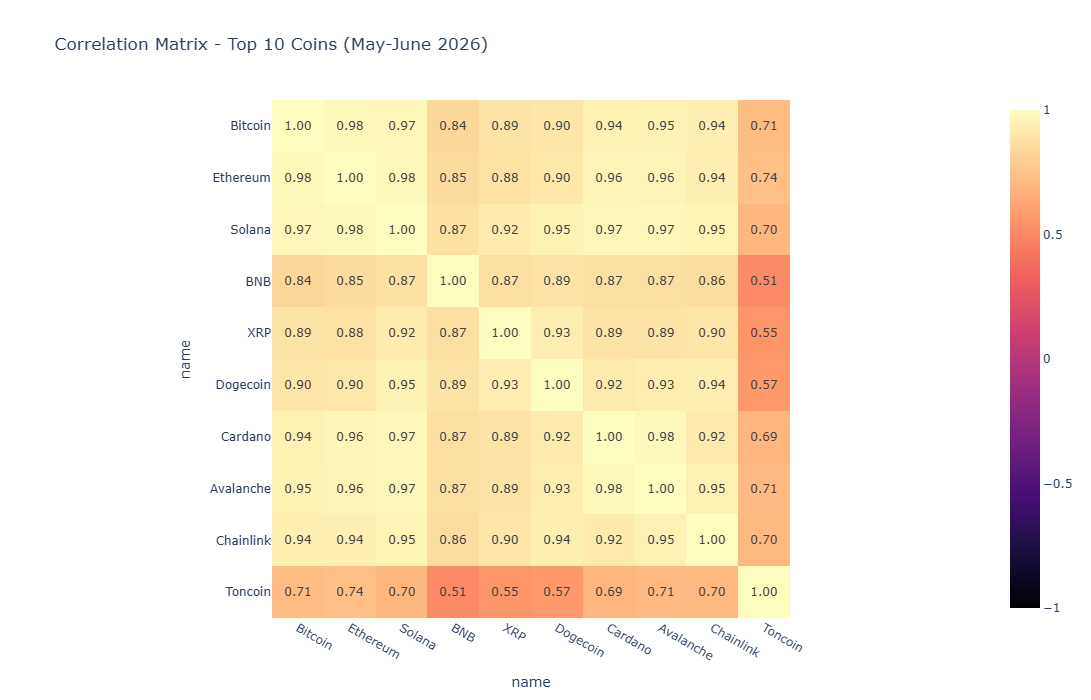

In [ ]:
top_coins = ['Bitcoin', 'Ethereum', 'Solana', 'BNB', 'XRP', 
             'Dogecoin', 'Cardano', 'Avalanche', 'Chainlink', 'Toncoin']

df_top_corr = df_pivot[top_coins]

corr = df_top_corr.corr()

fig = px.imshow(
    corr,
    title='Correlation Matrix - Top 10 Coins (May-June 2026)',
    color_continuous_scale='magma',
    zmin=-1, zmax=1,
    text_auto='.2f'
)

fig.update_layout(width=800, height=700)
fig.show()

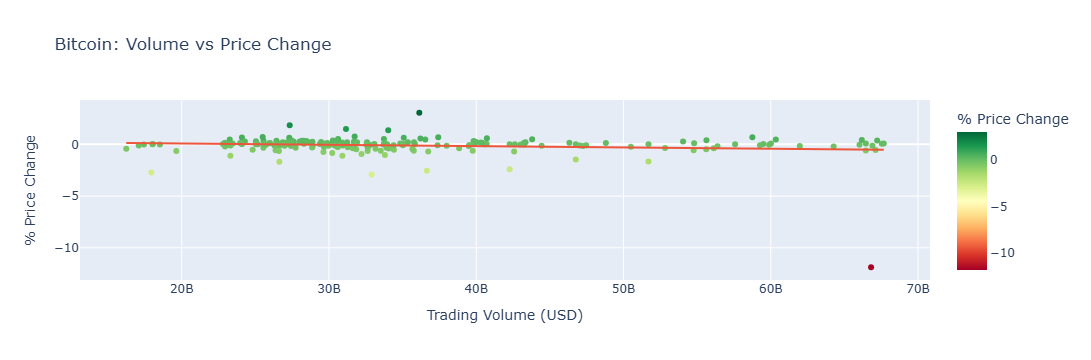

In [ ]:
# Focus on Bitcoin for this one
btc = df2[df2['name'] == 'Bitcoin'].copy()

fig = px.scatter(
    btc,
    x='total_volume',
    y='pct_change',
    title='Bitcoin: Volume vs Price Change',
    labels={'total_volume': 'Trading Volume (USD)', 'pct_change': '% Price Change'},
    trendline='ols',
    color='pct_change',
    color_continuous_scale='RdYlGn'
)

fig.show()

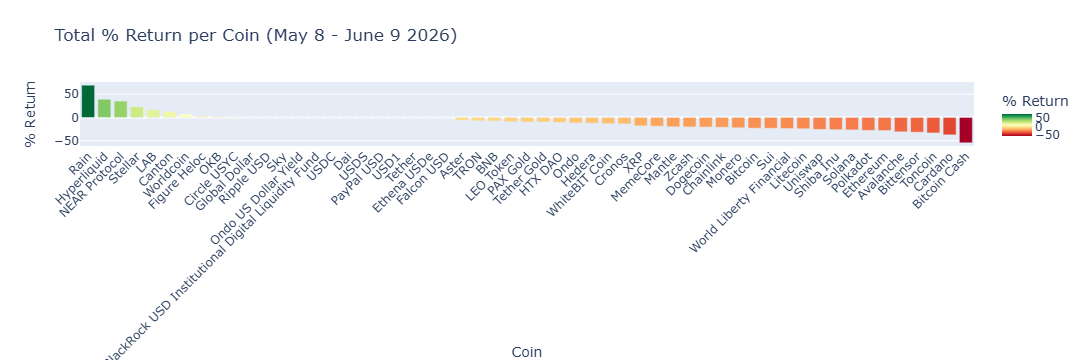

In [ ]:
# Get first and last price for each coin
first_price = df2.sort_values('ingested_at').groupby('name')['current_price'].first()
last_price = df2.sort_values('ingested_at').groupby('name')['current_price'].last()

# Calculate % return over the whole period
returns = ((last_price - first_price) / first_price * 100).reset_index()
returns.columns = ['name', 'total_return']
returns = returns.sort_values('total_return', ascending=False)

fig = px.bar(
    returns,
    x='name',
    y='total_return',
    title='Total % Return per Coin (May 8 - June 9 2026)',
    labels={'total_return': '% Return', 'name': 'Coin'},
    color='total_return',
    color_continuous_scale='RdYlGn'
)

fig.update_layout(xaxis_tickangle=-45)
fig.show()

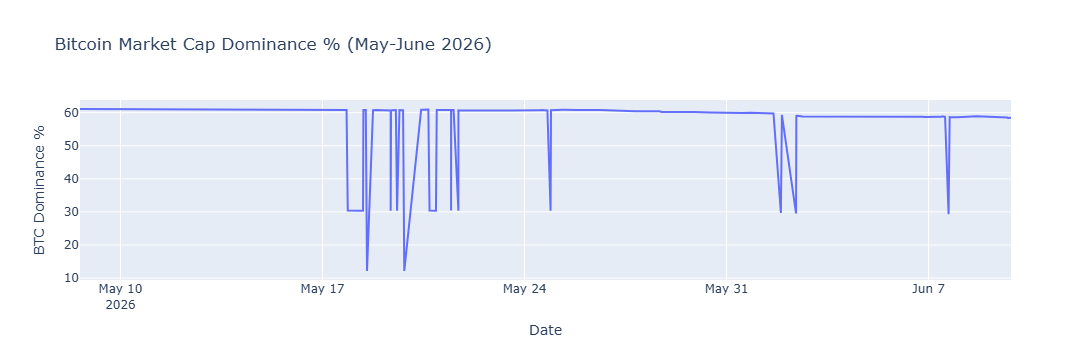

In [ ]:
# Total market cap per snapshot
total_mcap = df2.groupby('ingested_at')['market_cap'].sum().reset_index()
total_mcap.columns = ['ingested_at', 'total_market_cap']

# Bitcoin market cap over time
btc_mcap = df2[df2['name'] == 'Bitcoin'][['ingested_at', 'market_cap']].copy()

# Merge and calculate dominance
dominance = btc_mcap.merge(total_mcap, on='ingested_at')
dominance['btc_dominance'] = dominance['market_cap'] / dominance['total_market_cap'] * 100

fig = px.line(
    dominance,
    x='ingested_at',
    y='btc_dominance',
    title='Bitcoin Market Cap Dominance % (May-June 2026)',
    labels={'btc_dominance': 'BTC Dominance %', 'ingested_at': 'Date'}
)

fig.show()

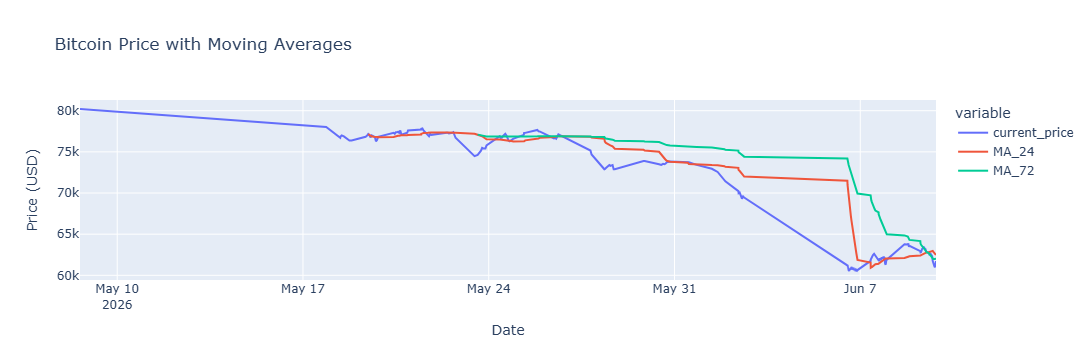

In [ ]:
btc = df2[df2['name'] == 'Bitcoin'].copy().sort_values('ingested_at')

btc['MA_24'] = btc['current_price'].rolling(window=24).mean()
btc['MA_72'] = btc['current_price'].rolling(window=72).mean()

fig = px.line(
    btc,
    x='ingested_at',
    y=['current_price', 'MA_24', 'MA_72'],
    title='Bitcoin Price with Moving Averages',
    labels={'value': 'Price (USD)', 'ingested_at': 'Date'}
)

fig.show()

In [ ]:
# Biggest single hour gains for Rain
rain = df2[df2['name'] == 'Rain'].copy().sort_values('ingested_at')

# Top 10 biggest single hour pumps
top_gains = rain.nlargest(10, 'pct_change')[['ingested_at', 'current_price', 'pct_change']]

print("Rain's Top 10 Single Hour Gains:")
print(top_gains.to_string(index=False))

Rain's Top 10 Single Hour Gains:
                     ingested_at  current_price  pct_change
2026-05-27 20:00:10.168000+03:00       0.013027   61.306763
2026-05-28 08:36:23.560000+03:00       0.014248    9.524040
2026-05-25 20:00:06.540000+03:00       0.007996    5.252627
2026-06-02 12:00:09.542000+03:00       0.014097    3.956935
2026-05-29 20:00:06.436000+03:00       0.014685    3.246695
2026-06-07 09:22:39.192000+03:00       0.013185    2.871536
2026-05-20 10:00:09.628000+03:00       0.007497    2.187997
2026-05-23 22:00:12.367000+03:00       0.007447    1.834815
2026-06-02 11:00:07.478000+03:00       0.013560    1.747339
2026-06-07 12:30:09.473000+03:00       0.013470    1.623200


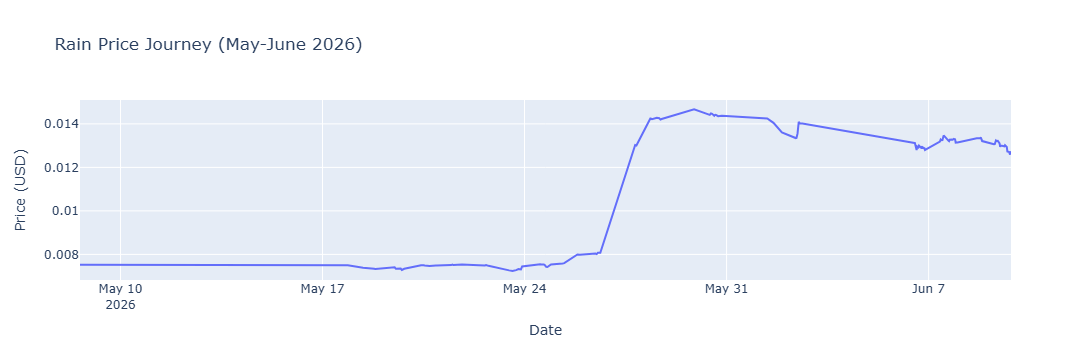

In [ ]:
fig = px.line(
    rain,
    x='ingested_at',
    y='current_price',
    title='Rain Price Journey (May-June 2026)',
    labels={'current_price': 'Price (USD)', 'ingested_at': 'Date'}
)

fig.show()

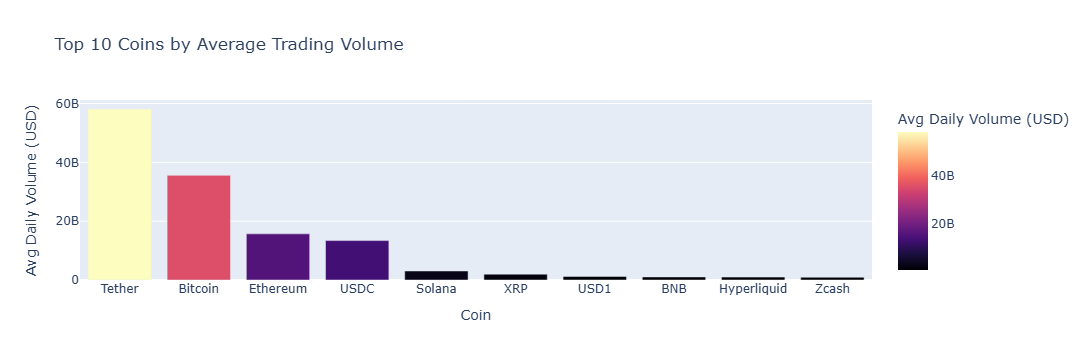

In [ ]:
vol_leaders = df2.groupby('name')['total_volume'].mean().reset_index()
vol_leaders.columns = ['name', 'avg_volume']
vol_leaders = vol_leaders.sort_values('avg_volume', ascending=False).head(10)

fig = px.bar(
    vol_leaders,
    x='name',
    y='avg_volume',
    title='Top 10 Coins by Average Trading Volume',
    labels={'avg_volume': 'Avg Daily Volume (USD)', 'name': 'Coin'},
    color='avg_volume',
    color_continuous_scale='magma'
)
fig.show()

In [ ]:
# Close duckdb Connection
conn.close()